# 1.Install (if needed) and Import Libraries

In [59]:
# Installation of pysentiment2 to get access to Loughran-McDonald Dictionary
# !pip install pysentiment2
# !pip install matplotlib
# !pip install openpyxl    


import pysentiment2 as ps
import numpy as np
import pandas as pd


# 2.Load the xlsx file and check the DataFrame

In [60]:
filename = "mda_processed_sample.xlsx"
data = pd.read_excel(filename, sheet_name="after_stopword_removal") # Use the sheet with stopwords removed

data.head()

# INFO:
# - doc column contains the document name
# - sent_{x} contains the sentence; NOTE: Not all documents have the same number of sentences


,doc,sent_1,sent_2,sent_3,sent_4,sent_5,sent_6,sent_7,sent_8,sent_9,...,sent_442,sent_443,sent_444,sent_445,sent_446,sent_447,sent_448,sent_449,sent_450,sent_451
0,NVIDIA_10-K_2010-03-18_MDA.txt,"overview, helped, awaken, world, power, comput...","expertise, programmable, gpus, led, breakthrou...","serve, entertainment, consumer, market, geforc...","last, several, years, operated, reported, four...","however, effective, first_year, longer, separa...","gpu_business, comprised, primarily, geforce, p...","psb, comprised, quadro_professional, workstati...","mcp, business, reported, year, comprised, prim...","ion, family, products, addresses, integrated, ...",...,"although, number, units, estimate, impacted, i...","weak_diepackaging_material, combination, used,...","continue, seek, access, insurance, coverage, r...","however_assurance, made, aggregate, million, c...","september, october, november, several, putativ...","please, note, financial, information_regarding...","contractual_obligations, represents, unrecogni...","unable, reasonably_estimate, timing_potential,...","adoption_new, accounting, pronouncements, plea...","recently, issued, accounting, pronouncements, ..."
1,NVIDIA_10-K_2011-03-16_MDA.txt,"overview, invented, graphics, processing, unit...","since, strived, new, standards, visual_computi...","expertise, programmable, gpus, computer-system...","strategically, investing, three, major, areas,...","serve, visual_computing, market, consumer, gef...","three, primary, financial, gpu, professional_s...","years, operated, reported, four, major, produc...","however, first_year, began, reporting, interna...","comparative, periods, presented, reflect, change",...,"recommended, customers, consider, changing, th...","intend, fully, support, custom, ers, repair, r...","weak_diepackaging_material, combination, used,...","september, october, november, several, putativ...","please, note, financial, information_regarding...","contractual_obligations, represents, unrecogni...","unable, reasonably_estimate, timing_potential,...","adoption_new, accounting, pronouncements, plea...","recently, issued, accounting, pronouncements, ...",NaN
2,NVIDIA_10-K_2012-03-13_MDA.txt,"overview, known, millions, around, world, crea...","invention, gpu, brought, world, power, compute...","today, reach, well, beyond, pc_graphics","energy-efficient, processors, power, broad, ra...","mobile, processors, used, cell, phones, tablet...","pc, gamers, rely, gpus, enjoy, visually, immer...","designers, use, create, visual, effects, movie...","researchers, utilize, gpus, push, frontiers, s...","nearly, patents, granted, pending, worldwide, ...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NVIDIA_10-K_2013-03-12_MDA.txt,"overview, visual_computing, connecting, people...","world, increasingly, filled, visual, displays,...","visualization, transcends, cultural, language,...","long, known, millions, around, world, creating...","invention, gpu, introduced, world, power, prog...","today, reach, well, beyond, pc_graphics, games","energy-efficient, processors, heart, products,...","pc, gamers, choose, gpus, name, enjoy, immersi...","tegra_processors, power, smartphones_tablets, ...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NVIDIA_10-K_2014-03-13_MDA.txt,"overview, visual_computing","world, increasingly, filled, visual, displays,...","strategy, world, leader, visual_computing","target, applications, major, computing_platfor...","target, markets, gaming, design, visualization...","deploy, business, models, believe, best, suite...","long, known, bringing, video, games, life, pc_...","invention, gpu, introduced, world, power, prog...","today, reach, well, beyond, pc_graphics, games",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# 3. Modify df so it returns 1 sentence per row, remove blank sentences as we don't need to do any analysis

In [61]:
# Split sentences into individual rows
df = data.copy()
df = data.melt(id_vars=["doc"], var_name="sentence_id", value_name="sentence")

df.head() # temp check its done correctly

# SIMPLE PROCESSING
# Drop NaNs for rows with empty sentences
df = df.dropna(subset=["sentence"])
# In case there are sentences that are empty but not marked NaN
df = df[df["sentence"].astype(str).str.strip() != ""]


# Ensure that the melted DF is still the same as the original DF
sentence_cols = [col for col in data.columns if col.startswith("sent_")]
mask = data[sentence_cols].apply(lambda col: col.map(lambda x: pd.notna(x) and str(x).strip() != ""))
original_nonempty_count = mask.sum().sum()
long_count = df.shape[0]

print("Original real sentence cells:", original_nonempty_count)
print("Rows in melted df:", long_count)
print("Match?", original_nonempty_count == long_count)

# Check
df.head()



Original real sentence cells: 11881
Rows in melted df: 11881
Match? True


,doc,sentence_id,sentence
0,NVIDIA_10-K_2010-03-18_MDA.txt,sent_1,"overview, helped, awaken, world, power, comput..."
1,NVIDIA_10-K_2011-03-16_MDA.txt,sent_1,"overview, invented, graphics, processing, unit..."
2,NVIDIA_10-K_2012-03-13_MDA.txt,sent_1,"overview, known, millions, around, world, crea..."
3,NVIDIA_10-K_2013-03-12_MDA.txt,sent_1,"overview, visual_computing, connecting, people..."
4,NVIDIA_10-K_2014-03-13_MDA.txt,sent_1,"overview, visual_computing"


# 4. Start scoring each sentence (using LM)

In [62]:
# Initialise
lm = ps.LM()

# For a sentence, score using LM and return Positive, Negative, Polarity, Subjectivity
def analyse_lm(text):
    tokens = lm.tokenize(str(text))
    score = lm.get_score(tokens)
    return pd.Series({ # Return so we can append to each row in df
        "positive": score["Positive"],
        "negative": score["Negative"],
        "polarity": score["Polarity"],
        "subjectivity": score["Subjectivity"]
    })

def analyse_lm_test(text):
    tokens = lm.tokenize(str(text))
    return lm.get_score(tokens)



# NOTE:
# Positive number is the word counts for words in positive set
# Negative number is the word counts for words in negative set
# Polarity calculated with P-N/P+N (Overall Sentiment)
# Subjectivity = P+N/Total Tokens (How many of the tokens were sentiment-bearing words)

In [63]:
# Feed each sentence to function, get the result
scores = df["sentence"].apply(analyse_lm)

# Combine scores to each row
df = pd.concat([df, scores], axis=1)


In [64]:
# JUST IN CASE, randomly check 5 rows to ensure that the calculations are done correctly and appended

import random
random_numbers_unique = random.sample(range(0, 11881), 5)


for num in random_numbers_unique:
    print(f"Checking row {num}")
    temp_sent = df.iloc[num]["sentence"]
    temp_result = analyse_lm_test(temp_sent)

    print(temp_result)
    
    # Compare results with the appended one
    appended = {
        "Positive": df.iloc[num]["positive"],
        "Negative": df.iloc[num]["negative"],
        "Polarity": df.iloc[num]["polarity"],
        "Subjectivity": df.iloc[num]["subjectivity"]
    }
    print(appended)

    print("positive match:", temp_result["Positive"] == appended["Positive"])
    print("negative match:", temp_result["Negative"] == appended["Negative"])
    print("polarity match:", temp_result["Polarity"] == appended["Polarity"])
    print("subjectivity match:", temp_result["Subjectivity"] == appended["Subjectivity"])
    



Checking row 7696
{'Positive': np.int64(0), 'Negative': np.int64(0), 'Polarity': np.float64(0.0), 'Subjectivity': np.float64(0.0)}
{'Positive': np.float64(0.0), 'Negative': np.float64(0.0), 'Polarity': np.float64(0.0), 'Subjectivity': np.float64(0.0)}
positive match: True
negative match: True
polarity match: True
subjectivity match: True
Checking row 5468
{'Positive': np.int64(0), 'Negative': np.int64(0), 'Polarity': np.float64(0.0), 'Subjectivity': np.float64(0.0)}
{'Positive': np.float64(0.0), 'Negative': np.float64(0.0), 'Polarity': np.float64(0.0), 'Subjectivity': np.float64(0.0)}
positive match: True
negative match: True
polarity match: True
subjectivity match: True
Checking row 11406
{'Positive': np.int64(0), 'Negative': np.int64(0), 'Polarity': np.float64(0.0), 'Subjectivity': np.float64(0.0)}
{'Positive': np.float64(0.0), 'Negative': np.float64(0.0), 'Polarity': np.float64(0.0), 'Subjectivity': np.float64(0.0)}
positive match: True
negative match: True
polarity match: True
subj

# 5. Aggregate into each document for sentiment analysis

In [65]:
doc_summary = df.groupby("doc").agg(
    num_sentences=("sentence", "count"),
    total_positive=("positive", "sum"),
    total_negative=("negative", "sum"),
    avg_polarity=("polarity", "mean"),
    avg_subjectivity=("subjectivity", "mean")
).reset_index()

doc_summary["net_sentiment"] = (
    doc_summary["total_positive"] - doc_summary["total_negative"]
)

doc_summary.head()


,doc,num_sentences,total_positive,total_negative,avg_polarity,avg_subjectivity,net_sentiment
0,NVIDIA_10-K_2010-03-18_MDA.txt,450,123.0,365.0,-0.283333,0.087239,-242.0
1,NVIDIA_10-K_2011-03-16_MDA.txt,448,145.0,348.0,-0.221056,0.082960,-203.0
2,NVIDIA_10-K_2012-03-13_MDA.txt,410,142.0,308.0,-0.193821,0.081164,-166.0
3,NVIDIA_10-K_2013-03-12_MDA.txt,400,125.0,279.0,-0.172250,0.074740,-154.0
4,NVIDIA_10-K_2014-03-13_MDA.txt,376,114.0,240.0,-0.155674,0.072715,-126.0


In [66]:
# Again, check that it matches the original data df in terms of sentences

sentence_cols = [col for col in data.columns if col.startswith("sent_")]

original_counts = data.copy()

original_counts["original_num_sentences"] = data[sentence_cols].apply(
    lambda row: sum(pd.notna(x) and str(x).strip() != "" for x in row),
    axis=1
)

original_counts = original_counts[["doc", "original_num_sentences"]]

check_df = original_counts.merge(
    doc_summary[["doc", "num_sentences"]],
    on="doc",
    how="inner"
)

check_df["match"] = (
    check_df["original_num_sentences"] == check_df["num_sentences"]
)

print(check_df.tail())
print("All match?", check_df["match"].all())

mismatches = check_df[check_df["match"] == False]
print(mismatches)

                               doc  original_num_sentences  num_sentences  \
59  NVIDIA_10-Q_2024-08-28_MDA.txt                     172            172   
60  NVIDIA_10-Q_2024-11-20_MDA.txt                     150            150   
61  NVIDIA_10-Q_2025-05-28_MDA.txt                     131            131   
62  NVIDIA_10-Q_2025-08-27_MDA.txt                     136            136   
63  NVIDIA_10-Q_2025-11-19_MDA.txt                     140            140   

    match  
59   True  
60   True  
61   True  
62   True  
63   True  
All match? True
Empty DataFrame
Columns: [doc, original_num_sentences, num_sentences, match]
Index: []


# 6. Do some cool visualisations

In [67]:
# Import libraries
import matplotlib.pyplot as plt

In [68]:
# Need to extract out the date and document type first

doc_summary["date"] = doc_summary["doc"].str.extract(r"(\d{4}-\d{2}-\d{2})")
doc_summary["date"] = pd.to_datetime(doc_summary["date"])
doc_summary["filing_type"] = doc_summary["doc"].str.extract(r"(10-K|10-Q)")


In [69]:
doc_summary.head()
print(doc_summary["filing_type"].value_counts())

filing_type
10-Q    48
10-K    16
Name: count, dtype: int64


In [70]:
# Sort by 10-K and 10-Q
df_10k = doc_summary[doc_summary["filing_type"] == "10-K"].copy()
df_10k = df_10k.sort_values("date")
print("10-K Rows:", df_10k.shape[0])

df_10q = doc_summary[doc_summary["filing_type"] == "10-Q"].copy()
df_10q = df_10q.sort_values("date")
print("10-Q Rows:", df_10q.shape[0])



10-K Rows: 16
10-Q Rows: 48


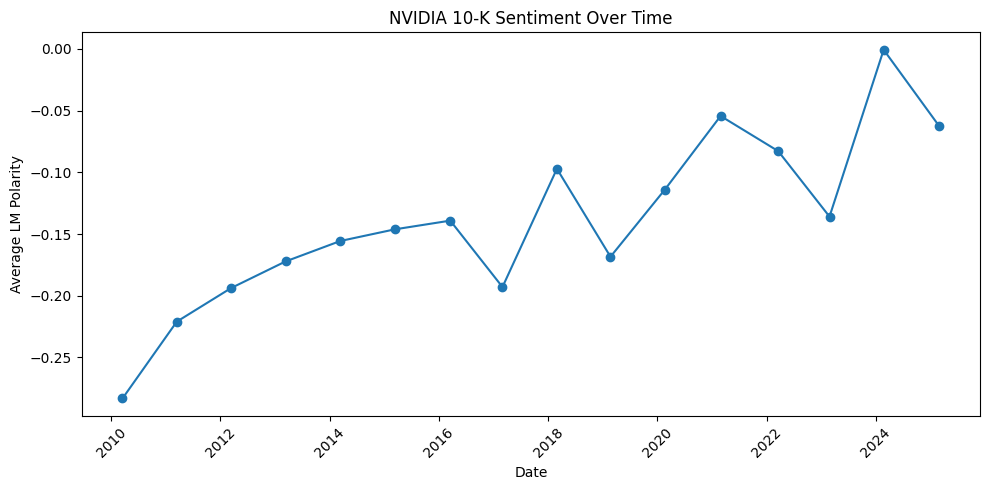

In [73]:
# Plot by 10-K
plt.figure(figsize=(10, 5))
plt.plot(df_10k["date"], df_10k["avg_polarity"], marker="o")
plt.xlabel("Date")
plt.ylabel("Average LM Polarity")
plt.title("NVIDIA 10-K Sentiment Over Time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Higher polarity means more positive language

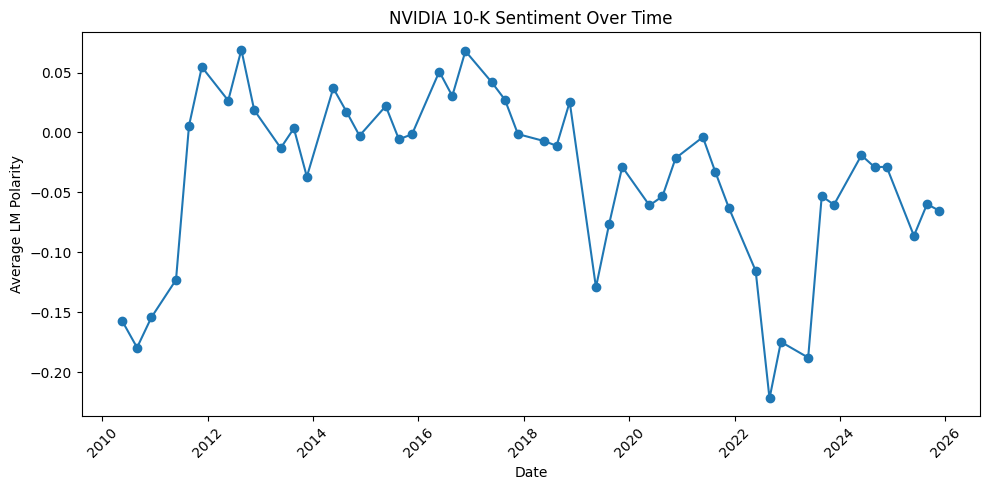

In [ ]:
# Plot by 10-Q
plt.figure(figsize=(10, 5))
plt.plot(df_10q["date"], df_10q["avg_polarity"], marker="o")
plt.xlabel("Date")
plt.ylabel("Average LM Polarity")
plt.title("NVIDIA 10-K Sentiment Over Time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Higher polarity means more positive language